<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
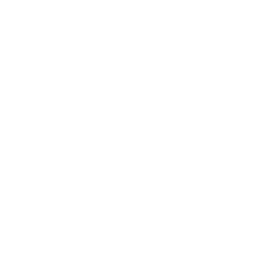
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrapové intervaly spolehlivosti pro cílové ukazatele klinické studie</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutická / klinická biostatistika &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí

Tento příklad počítá **neparametrický bootstrapový interval spolehlivosti** pro cílový ukazatel přežití pomocí **PROC IML**, maticového programovacího jazyka SAS. Cílovým ukazatelem je **poměr mediánů přežití bez progrese (PFS)** mezi léčenou a kontrolní skupinou malé dvouramenné onkologické kohorty.

IML program načte data na úrovni subjektů do matic, vypočte pozorovaný poměr mediánů PFS, vylosuje **2 000 bootstrapových výběrů** s vracením pomocí `CALL RANDGEN`, přepočítá poměr v každém výběru pomocí maticových operací a odvodí **korigovaný a zrychlený (BCa)** interval spolehlivosti. BCa je zde vhodnou volbou, protože bootstrapové rozdělení poměru mediánů je zdola omezené nulou, diskrétní a zešikmené &mdash; podmínky, za kterých je prostý interval založený na normálním rozdělení nespolehlivý.

Celá analýza probíhá uvnitř IML: korekční konstanta zkreslení *z*<sub>0</sub>, zrychlení *a&#770;* z jackknifu typu leave-one-out a upravené percentilové koncové body jsou sestaveny z maticových výrazů a standardních normálních funkcí `PROBNORM` a malého modulu inverzní normální funkce. Každé níže uvedené číslo je čteno přímo z výstupu IML.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Čas PFS, indikátor události, rameno studie a výchozí kovariáty za každý subjekt | 100 |

Kohorta je **vyvážená** &mdash; 50 subjektů na rameno &mdash; přiřazením ramene podle parity identifikátoru subjektu, takže obě ramena jsou při převzorkování plně zastoupena.

---


In [1]:
/* --------------------------------------------------------
   Vygeneruj syntetickou dvouramennou onkologickou kohortu.
   Časy PFS mají lognormální rozdělení; léčené rameno je
   posunuto k delšímu mediánu. Příslušnost k ramenu se střídá
   podle parity identifikátoru subjektu, takže je kohorta
   vyvážená 50/50.
   -------------------------------------------------------- */
data work.trial_subjects;
    CALL streaminit(42);
    DÉLKA arm_label $20;
    OPAKUJ subject_id = 1 TO 500;
        /* 1 = Léčba, 0 = Kontrola (vyváženo podle parity) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'LÉČBA', 'KONTROLA');
        /* Čas PFS v měsících: léčené rameno má delší přežití */
        KDYŽ arm = 1 PAK
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        JINAK
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        KDYŽ pfs_months < 0.5 PAK pfs_months = 0.5;
        /* Indikátor události: ~75 % subjektů mělo událost progrese */
        EVENT = (rand('uniform') > 0.25);
        /* Výchozí kovariáty */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        KDYŽ AGE < 25 PAK AGE = 25;
        KDYŽ AGE > 85 PAK AGE = 85;
        VÝSTUP;
    KONEC;
SPUSTIT;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                                    Přehled přežití bez progrese podle ramene studie                                    

                                                  The MEANS Procedure

                                     Analysis Variable : pfs_months PFS (měsíce)

        Rameno studie          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------------------
        KONTROLA                  50          10.74           7.20           9.86           1.90          53.70
        LÉČBA                     50          13.94          10.10          11.95           2.70          79.10
        -------------------------------------------------------------------------------------------------------

                                              Analysis Variable : AGE Věk

        Rameno studie          N Obs           Mean         Median        Std Dev        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


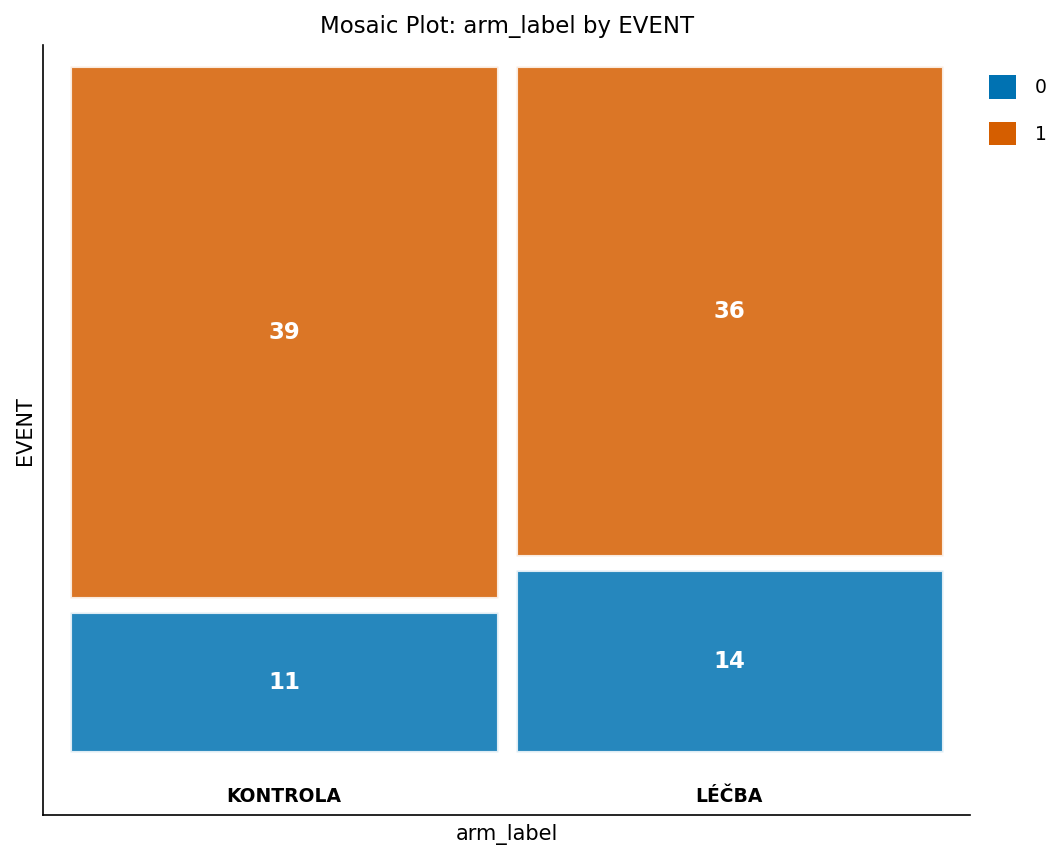

In [2]:
/* --------------------------------------------------------
   Výchozí přehled PFS a míra událostí podle ramene studie
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    TŘÍDA arm_label;
    PROMĚNNÁ pfs_months AGE;
    ŠTÍTEK arm_label="Rameno studie" pfs_months="PFS (měsíce)" AGE="Věk";
    NÁZEV 'Přehled přežití bez progrese podle ramene studie';
SPUSTIT;

PROCEDURA ČETNOSTI data=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    ŠTÍTEK arm_label="Rameno studie" EVENT="Událost";
    NÁZEV 'Počty událostí podle ramene studie';
SPUSTIT;

---


In [3]:
/* --------------------------------------------------------
   PROC IML: neparametrický bootstrap pro poměr mediánů PFS,
   s BCa intervalem spolehlivosti.

   Kroky:
   1. Načíst data studie do matic IML
   2. Vypočítat pozorovaný poměr mediánů PFS (časy událostí)
   3. Vylosovat 2 000 bootstrapových výběrů pomocí CALL RANDGEN
   4. Přepočítat poměr v každém výběru
   5. BCa korekce: z0 (zkreslení) + zrychlení z jackknifu
   6. Zapsat bootstrapové rozdělení do datasetu SAS
   -------------------------------------------------------- */
PROCEDURA IML;

    /* --- Modul: medián PFS podle ramene a jejich poměr --- */
    /* Medián se počítá pouze z pozorovaných časů událostí, což
       je obvyklé neparametrické shrnutí, když u většiny subjektů
       dojde k progresi. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        KDYŽ nrow(trt_pfs) = 0 PAK trt_med = .;
        JINAK trt_med = MEDIAN(trt_pfs);
        KDYŽ nrow(ctl_pfs) = 0 PAK ctl_med = .;
        JINAK ctl_med = MEDIAN(ctl_pfs);
        KDYŽ ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            PAK RATIO = trt_med / ctl_med;
        JINAK RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Modul: inverzní distribuční funkce standardního
       normálního rozdělení (probit) --- */
    /* Racionální aproximace (Abramowitz & Stegun 26.2.23);
       spolu s PROBNORM poskytuje koncové body z0 / z-alfa,
       které BCa úprava potřebuje. */
    START probit(p);
        KDYŽ p <= 0 PAK RETURN(-1e8);
        KDYŽ p >= 1 PAK RETURN( 1e8);
        KDYŽ p < 0.5 PAK OPAKUJ; sgn = -1; pp = p;     KONEC;
        JINAK            OPAKUJ; sgn =  1; pp = 1 - p; KONEC;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Načtení dat do matic --- */
    USE work.trial_subjects;
        READ ALL VAR {pfs_months} INTO pfs;
        READ ALL VAR {arm}        INTO arm;
        READ ALL VAR {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    TISK 'Subjekty načtené do IML', n n_trt n_ctl;

    /* --- 2. Pozorovaná statistika na celém vzorku --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Trt_Median Ctl_Median RATIO};
    TISK 'Pozorovaný medián PFS (časy událostí) podle ramene',
          obs[COLNAME=obs_lab FORMAT=8.3];

    /* --- 3. Bootstrapová smyčka převzorkování (2 000 výběrů) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    OPAKUJ b = 1 TO n_boot;
        CALL randgen(u, 'Uniform');     /* nová tažení při každém průchodu */
        idx = ceil(n # u);              /* indexy 1..n s vracením */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    KONEC;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CALL SORT(bv, 1);

    /* --- 4. Prostý percentilový interval (pro srovnání) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa korekce --- */
    /* z0: korekce zkreslení z podílu výběrů pod pozorovanou
       statistikou. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a_hat: zrychlení z jackknifu typu leave-one-out. */
    jack = j(n, 1, .);
    OPAKUJ i = 1 TO n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    KONEC;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Upravené percentilové pozice. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Valid Prop_Below z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    TISK 'Diagnostika korekce BCa',
          diag[COLNAME=diag_lab FORMAT=8.4];

    ci_lab = {Obs_Ratio Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    TISK '95% CI pro poměr mediánů PFS (léčba / kontrola)',
          ci_row[COLNAME=ci_lab FORMAT=8.4];

    /* --- 6. Uložení bootstrapového rozdělení --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                           Počty událostí podle ramene studie                                           

Subjekty načtené do IML
     100
      50
      50

Pozorovaný medián PFS (časy událostí) podle ramene
   9.900   7.100   1.394

Diagnostika korekce BCa
2000.0000  0.5340  0.0851 -0.0021

95% CI pro poměr mediánů PFS (léčba / kontrola)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.05 seconds
  cpu   2.05 seconds


---


In [4]:
/* --------------------------------------------------------
   Uprav bootstrapové rozdělení pro vykreslení: dej sloupcům
   popisné názvy pro histogram níže.
   -------------------------------------------------------- */
data work.bootstrap_results;
    NASTAVIT work.bootstrap_results
        (RENAME=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
SPUSTIT;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                           Počty událostí podle ramene studie                                           




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


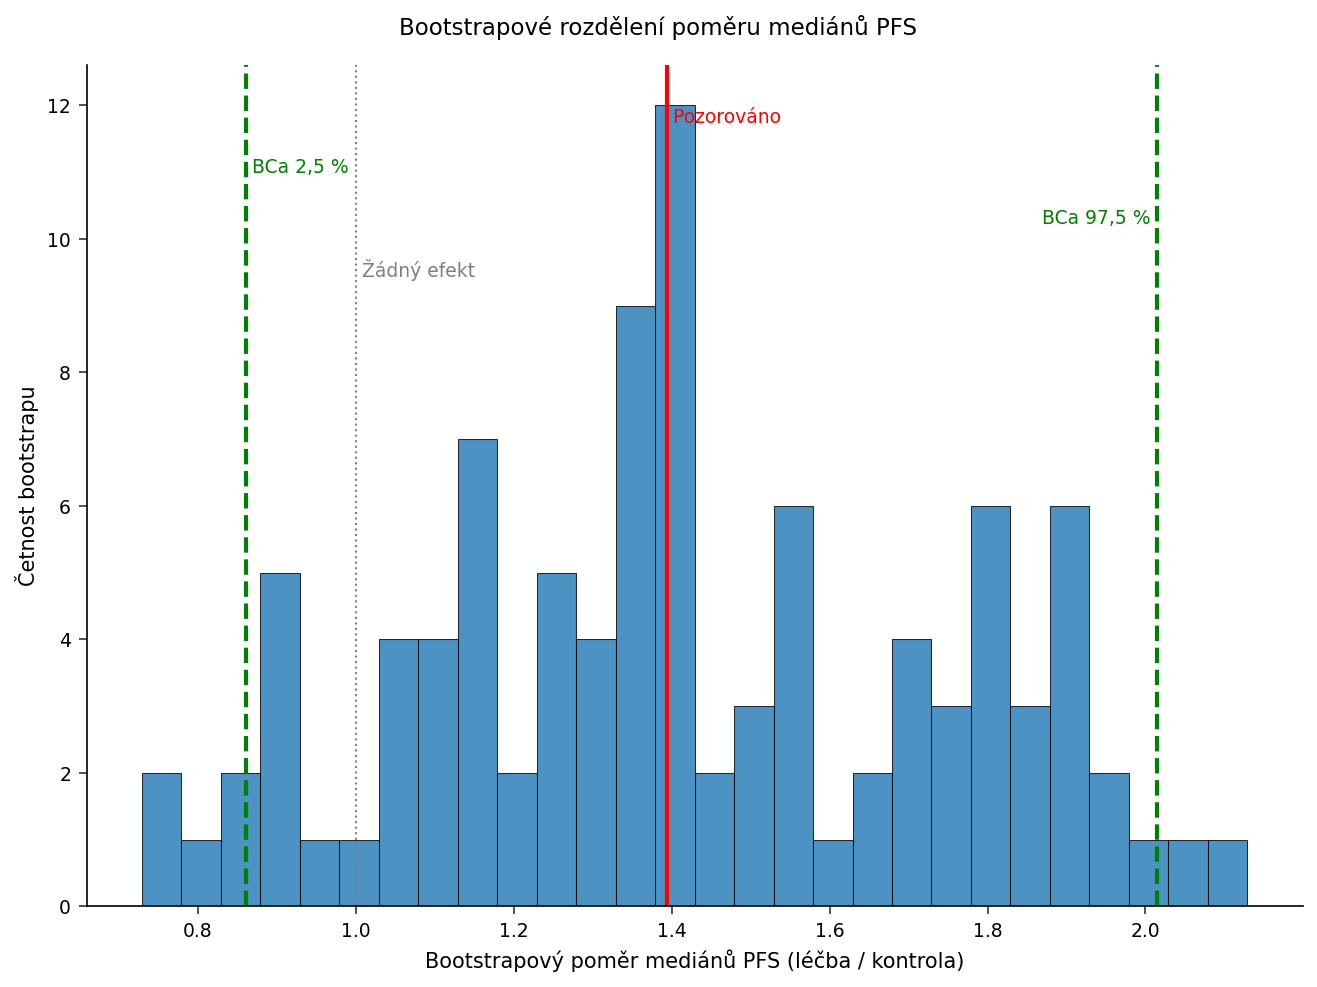

In [5]:
/* --------------------------------------------------------
   Bootstrapové rozdělení poměru mediánů PFS s vyznačeným
   pozorovaným odhadem a BCa intervalem.
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) LABEL='Pozorováno';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        LABEL='BCa 2,5 %';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        LABEL='BCa 97,5 %';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        LABEL='Žádný efekt';
    XAXIS LABEL='Bootstrapový poměr mediánů PFS (léčba / kontrola)';
    YAXIS LABEL='Četnost bootstrapu';
    NÁZEV 'Bootstrapové rozdělení poměru mediánů PFS';
SPUSTIT;

---


### Interpretace

V této kohortě je pozorovaný medián PFS podle časů událostí **9,9 měsíce** v léčeném rameni a **7,1 měsíce** v kontrolním rameni, tedy **poměr 1,394** &mdash; medián PFS v experimentálním rameni je asi o 39 % delší. IML program převzorkoval 100 subjektů 2 000krát; všech 2 000 výběrů poskytlo definovaný poměr.

**95% BCa interval spolehlivosti pro poměr je [0,86, 2,01]**, oproti prostému percentilovému intervalu **[0,82, 1,97]**. Oba intervaly **zahrnují hodnotu 1,0**, takže při této velikosti vzorku &mdash; zhruba 50 subjektů na rameno, dále zúžených na pozorované časy událostí &mdash; není zdánlivý přínos **statisticky průkazný**. To je poctivé sdělení této analýzy: bodový odhad ve prospěch léčby, avšak s dostatečnou nejistotou z převzorkování na to, aby nebylo možné vyloučit nulový efekt léčby.

Diagnostika BCa kvantifikuje, o kolik korekce posunula koncové body. Člen zkreslení je malý (**z<sub>0</sub> = 0,085**: zhruba 53 % výběrů bylo pod pozorovaným poměrem, blízko symetrickým 50 %) a zrychlení je téměř nulové (**a&#770; = -0,002**), což naznačuje, že poměr mediánů PFS je jednotlivými subjekty ovlivněn jen mírně. Protože jsou z0 i a&#770; malé, BCa posouvá interval oproti percentilovému intervalu jen nepatrně nahoru &mdash; přesně tak mírnou korekci tato diagnostika předpovídá.

Větší studie by tento interval zúžila. Při 50 subjektech na rameno bootstrap správně hlásí, že data jsou slučitelná s čímkoli od mírného obrácení efektu až po zdvojnásobení mediánu PFS, a proto studie s dostatečnou silou k detekci rozdílu PFS této velikosti potřebuje podstatně více než 100 subjektů.

---


In [6]:
/* --------------------------------------------------------
   Export bootstrapového rozdělení pro přílohu zprávy.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>